# PRF analysis

In [1]:
%load_ext autoreload
%load_ext usnm2p.skip_kernel_extension
%autoreload 2

## Imports

In [2]:
# External packages
import os
import jupyter_slack
import datetime
import itertools
import matplotlib.colors as mcolors
from statannotations.Annotator import Annotator
import diptest
from scipy.stats import ttest_1samp, shapiro

# Internal modules
from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.utils import *
from usnm2p.indexers import *
from usnm2p.fileops import *
from usnm2p.postpro import *
from usnm2p.plotters import *
from usnm2p.batchutils import *
from usnm2p.surrogates import generate_surrogate
from usnm2p.parsers import extract_FOV_area, resolve_mouseline

# Figures dictionary
figs = {}

## Parameters

### Input datasets and main processing parameters

In [3]:
# Processing parameters
analysis_type = 'PRF'  # Analysis type
mouseline = 'theo_line3'  # mouse line
layer = None  # cortical layer
slack_notify = False
global_correction = GLOBAL_CORRECTION  # global stack correction method
kalman_gain = KALMAN_GAIN  # gain of Kalman filter
neuropil_scaling_coeff = NEUROPIL_SCALING_COEFF  # scaling coefficient for neuropil subtraction
baseline_quantile = BASELINE_QUANTILE  # evaluation quantile for baseline computation
baseline_wquantile = BASELINE_WQUANTILE  # quantile filter window size (s) to compute fluorescence baseline
baseline_wsmoothing = BASELINE_WSMOOTHING  # gaussian filter window size (s) to smooth out fluorescence baseline
trial_aggfunc = TRIAL_AGGFUNC  # trial aggregation function
ykey_classification = YKEY_CLASSIFICATION  # Reference variable for response classification
directional = DIRECTIONAL_DETECTION  # whether to look for directional (i.e. positive only) effect for response detection

ykeys_plt = [  # plotting variables
    Label.DFF,
    Label.ZSCORE,
]
plot_rasters = True  # whether to render raster plots of population activity, or not
plot_traces = True  # whether to render traces of population activity, or not

### Derived parameters

In [4]:
# GCaMP channel key
gcamp_key = get_gcamp_key(mouseline)

# If global correction is dictionary, extract line-specific method
if isinstance(global_correction, dict):
    global_correction = global_correction[mouseline]

# Get batch-related settings
dataset_group_id, input_dir, figsdir, figs_suffix = get_batch_settings(
    analysis_type, mouseline, layer, global_correction, kalman_gain, neuropil_scaling_coeff,
    baseline_quantile, baseline_wquantile, baseline_wsmoothing,
    trial_aggfunc, ykey_classification, directional)
baseline_id = get_baseline_id(baseline_quantile, baseline_wquantile, baseline_wsmoothing)

# Set ON/OFF execution flags
skip_rasters = not plot_rasters
skip_traces = not plot_traces
 
# Get time stamp from notebook start
tstamp_start = datetime.datetime.now()
fmts = ['%Y-%m-%d', '%H:%M:%S']
# Log start process
s = f'{dataset_group_id} {analysis_type} analysis notebook started on {tstamp_start.strftime(fmts[0])} at {tstamp_start.strftime(fmts[1])}'
if slack_notify:
    jupyter_slack.notify_self(s)
logger.info(s)

 2026/10/05 10:55:20: assembling batch analysis settings...
 2026/10/05 10:55:20: theo_line3 PRF analysis notebook started on 2026-10-05 at 10:55:20


### Input summary table figure

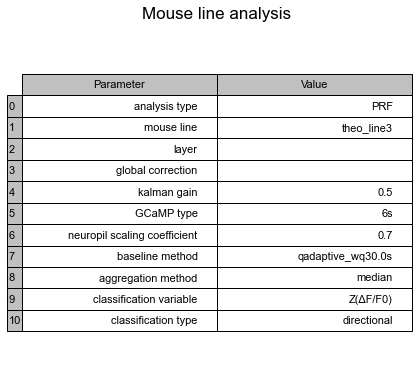

In [5]:
figs['dataset_info'] = plot_table({
    'analysis type': analysis_type,
    'mouse line': mouseline,
    'layer': layer,
    'global correction': global_correction,
    'kalman gain': kalman_gain,
    'GCaMP type': gcamp_key,
    'neuropil scaling coefficient': neuropil_scaling_coeff,
    'baseline method': baseline_id,
    'aggregation method': trial_aggfunc.__name__,
    'classification variable': ykey_classification,
    'classification type': f"{'' if directional else 'non '}directional",
    }, title='Mouse line analysis', aspect=1.5)

## Load & inspect initial data

### Load data

In [6]:
# Determine what to do in case of duplicate runs
on_duplicate_runs = 'drop_first'

# Load datasets
logger.info(f'loading data from {input_dir}:')
data = load_processed_datasets(
    input_dir, layer=layer,
    exclude_patterns=None,
    on_duplicate_runs=on_duplicate_runs)
logger.info('data successfully loaded.')

 2026/10/05 10:55:21: loading data from /Users/tlemaire/Documents/data/usnm/processed/aggmedian_classzscore_directional/alpha0.7_qadaptive_wq30.0s/suite2p_fs_3.58_reg_tif_tau_1.25/kd_G0.5_V0.05_npad10/submap_0<-1_stim-1->stimeverytrial/PRF/theo_line3:
 2026/10/05 10:55:21: gathering dataset IDs...
 2026/10/05 10:55:21: loading mouse-region data from 20260925_TR1684_region1.h5
 2026/10/05 10:55:21: loading mouse-region data from 20260928_DT1684_region1.h5
 2026/10/05 10:55:21: loading mouse-region data from 20260928_TR1684_region1.h5
 2026/10/05 10:55:22: loading mouse-region data from 20260929_DT1738_region1.h5
 2026/10/05 10:55:22: loading mouse-region data from 20260929_TR1684_region1.h5
 2026/10/05 10:55:22: assembling data structures...
 2026/10/05 10:55:25: harmonizing run index by param across datasets
 2026/10/05 10:55:25: generating expanded conditions...
 2026/10/05 10:55:30: expanding "triagg_stats" condition to match "trialagg_timeseries" timeseries
 2026/10/05 10:55:32: exp

### Unpack data and get ROI counts

In [ ]:
# Unpack
trialagg_timeseries, popagg_timeseries, trialagg_stats, ext_stats, ROI_masks, map_ops = extract_from_batch_data(data)

# Round ISPPA and ISPTA values to 2 decimal places for better readability
for k in [Label.ISPPA, Label.ISPTA]:
    if k in trialagg_stats.columns:
        trialagg_stats[k] = trialagg_stats[k].round(2)

# Determine dataset order for plotting
dataset_order = trialagg_stats.index.unique(level=Label.DATASET).sort_values().tolist()

# Check for NaN values in trial-aggregated statistics, and drop columns containing NaNs
nansums = trialagg_stats.isna().sum()
todelete = nansums[nansums > 0].index.tolist()
if len(todelete) > 0:
    logger.warning(f'deleting {todelete} columns from trialagg_stats because they contain NaN values')
    trialagg_stats.drop(columns=todelete, inplace=True)

# Add unified condition column to trial-aggregated statistics
logger.info('adding unified condition column to trial-aggregated statistics')
varying_params = get_varying_params(trialagg_stats)
cond_key = get_unified_condition_key(trialagg_stats[varying_params])
trialagg_stats[cond_key] = get_unified_condition_values(trialagg_stats[varying_params])

# Add unified condition column to trial-aggregated statistics, excluding PRF
logger.info('adding unified condition (excluding PRF) column to trial-aggregated statistics')
other_params = list(set(varying_params) - {Label.PRF})
other_cond_key = get_unified_condition_key(trialagg_stats[other_params])
trialagg_stats[other_cond_key] = get_unified_condition_values(trialagg_stats[other_params])

# Sort conditions by values of underlying parameters
l = []
for i, p in enumerate(varying_params):
    name, unit = parse_label(p)
    l.append(f'(?P<param{i}>{Pattern.FLOAT})\s*{unit}')
s = ', '.join(l)
conds = trialagg_stats[cond_key].groupby(Label.RUN).first()
sort_keys = conds.str.extract(s).astype(float)
sorted_conds = (
    pd.DataFrame({'label': conds})
    .join(sort_keys)
    .sort_values(
        sort_keys.columns.to_list(),
        kind='stable',
    )['label']
)

# Extract number of frames per trial from timeseries multi-index
nframes_per_trial = popagg_timeseries.index.unique(level=Label.FRAME).max() + 1

# Assemble frame indexer object
tref = get_stim_onset_time(mouseline)
fps = get_singleton(trialagg_stats, Label.FPS)
fidx = FrameIndexer.from_time(tref, TPRE, TPOST, 1 / fps, npertrial=nframes_per_trial)

# # TEMPORARY FIX: Offset population-aggregated traces by their median values
# logger.warning('TEMP FIX: computing ΔF/F and z-score traces median values for each dataset & run...')
# ykeys_offset = [Label.DFF, Label.ZSCORE]
# ymeds = popagg_timeseries[ykeys_offset].groupby([Label.DATASET, Label.RUN]).median()
# logger.warning('TEMP FIX: offseting median values from traces...')
# popagg_timeseries[ykeys_offset] -= expand_to_match(ymeds, popagg_timeseries.index)

# Display ROI count per dataset & run, and highlight incomplete datasets
logger.info('detailed ROI count:')
get_detailed_ROI_count(trialagg_stats, style=True)

 2026/10/05 10:55:33: extracting timeseries and stats from data...
 2026/10/05 10:55:33: deleting ['P, DC, PRF', 'P, PRF'] columns from trialagg_stats because they contain NaN values
 2026/10/05 10:55:34: adding unified condition column to trial-aggregated statistics
 2026/10/05 10:55:34: adding unified condition (excluding PRF) column to trial-aggregated statistics
 2026/10/05 10:55:34: detailed ROI count:


run,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
P (MPa),0.53,0.53,0.53,0.53,0.53,0.67,0.67,0.67,0.67,0.67,0.75,0.75,0.75,0.75,0.75,0.87,0.87,0.87,0.87,0.87,0.95,0.95,0.95,0.95,0.95,1.23,1.23,1.23,1.23,1.23
DC (%),80.00,80.00,80.00,80.00,80.00,50.00,50.00,50.00,50.00,50.00,80.00,80.00,80.00,80.00,80.00,30.00,30.00,30.00,30.00,30.00,50.00,50.00,50.00,50.00,50.00,30.00,30.00,30.00,30.00,30.00
PRF (Hz),10.00,100.00,1000.00,30.00,300.00,10.00,100.00,1000.00,30.00,300.00,10.00,100.00,1000.00,30.00,300.00,10.00,100.00,1000.00,30.00,300.00,10.00,100.00,1000.00,30.00,300.00,10.00,100.00,1000.00,30.00,300.00
dataset,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
20260925_TR1684_region1,556,556,556,556,556,nan,nan,nan,nan,nan,556,556,556,556,556,556,556,556,556,556,nan,nan,nan,nan,nan,556,556,556,556,556
20260928_DT1684_region1,nan,nan,nan,nan,nan,61,61,61,61,61,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,61,61,61,61,61,nan,nan,nan,nan,nan
20260928_TR1684_region1,nan,122,122,122,122,nan,nan,nan,nan,nan,nan,122,122,122,122,nan,122,122,122,122,nan,nan,nan,nan,nan,nan,122,122,122,122
20260929_DT1738_region1,42,42,nan,42,nan,nan,nan,nan,nan,nan,42,42,42,42,42,nan,42,42,42,42,nan,nan,nan,nan,nan,42,42,nan,42,42
20260929_TR1684_region1,757,757,757,757,757,nan,nan,nan,nan,nan,757,757,757,757,757,757,757,757,757,757,nan,nan,nan,nan,nan,757,757,757,757,757


### Inspect cell maps and exclude outlier datasets 

 2026/10/05 10:55:34: sorted cell densities:
dataset
20260929_DT1738_region1     165.580189
20260928_DT1684_region1     240.485513
20260928_TR1684_region1     480.971025
20260925_TR1684_region1    2191.966311
20260929_TR1684_region1    2984.385786
dtype: float64
 2026/10/05 10:55:34: plotting cell maps...


100%|██████████| 5/5 [00:00<00:00, 74.46it/s]

 2026/10/05 10:55:35: no exclusion criterion -> ignoring


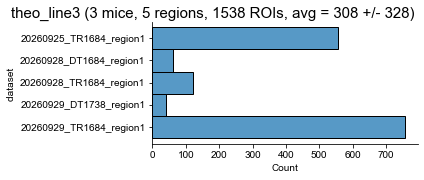

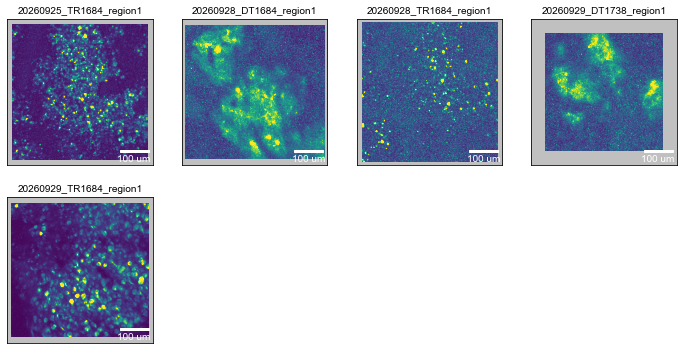

In [8]:
figs['cellcounts'] = plot_cellcounts(trialagg_stats, hue=None, title=mouseline)

# Compute ROI density for each dataset
FOV_areas = pd.Series({k: extract_FOV_area(v) for k, v in map_ops.items()})  # mm2
ROI_counts = get_detailed_ROI_count(trialagg_stats).max(axis=1).astype(int)  # cells
ROI_densities = ROI_counts / FOV_areas  # cells/mm2
logger.info(f'sorted cell densities:\n{ROI_densities.sort_values()}')

# If threshold on cell density is specified, exclude datasets with densities below threshold 
outliers = None
if MIN_CELL_DENSITY[mouseline] is not None:
    isoutlier = ROI_densities < MIN_CELL_DENSITY[mouseline]
    outliers = isoutlier[isoutlier].index.values.tolist()
    if len(outliers) > 0:
        logger.warning(f'datasets with abnormally low cell density::\n{pprint.pformat(outliers)}')
    figs['cellcounts'].axes[0].axvline(
        MIN_CELL_DENSITY[mouseline] * FOV_areas.mean(), c='k', ls='--')

# Plot cell maps and highlight outlier datasets
figs['cellmaps'] = plot_fields_of_view(
    map_ops, 
    refkey='max_proj',
    # ROI_masks=ROI_masks, 
    Fstats=trialagg_stats, 
    mode='contour', 
    hue=None, 
    outliers=outliers,
    qmax=.99
)

# Exclude outlier datasets
trialagg_timeseries, popagg_timeseries, trialagg_stats, ext_stats, ROI_masks = filter_datasets(
    trialagg_timeseries, popagg_timeseries, trialagg_stats, ext_stats, ROI_masks, exclude=outliers)

### Inspect baseline variation throughout experiments and exclude outlier datasets

 2026/10/05 10:55:35: inspecting relative variations in baseline fluorescence across experiments...
 2026/10/05 10:55:35: maximal relative FO deviations:
dataset
20260928_DT1684_region1    0.139606
20260929_TR1684_region1    0.141110
20260925_TR1684_region1    0.230498
20260928_TR1684_region1    0.290062
20260929_DT1738_region1    0.425528
Name: rel F0 (a.u.), dtype: float64


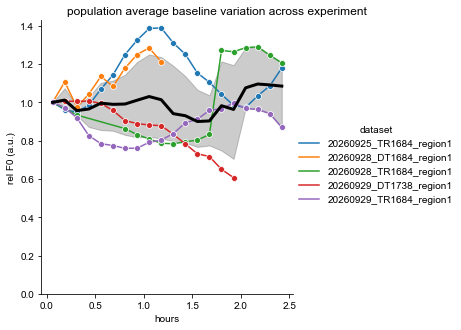

In [9]:
runid_maps = trialagg_stats[Label.RUNID].groupby([Label.DATASET, Label.RUN]).first()

def get_rel_F0(data, F0_key=Label.F0, aggbyrun=True):
    ''' Extract temporal evolution of F0 over experiment '''
    # Figure out dataset ID and associated run order
    dataset_id = data.index.unique(Label.DATASET)[0]
    # Add time along entire experiment to population-average dataframe average
    idx = get_index_along_experiment(data.index, runid_map=runid_maps.loc[dataset_id])
    data[Label.TIME] = idx / fps
    # If specified, aggregate by run
    if aggbyrun:
        data = data.groupby(Label.RUN).median()
    # Compute relative variation from max
    yref = data.sort_values(Label.TIME)[F0_key].iloc[0]
    # yref = data[F0_key].max()
    relF0_key = f'rel {F0_key}'
    data[relF0_key] = data[F0_key] / yref
    # Return data of interest
    return data[[Label.TIME, relF0_key]]

# Compute relative variation of average baseline along experiment, for each dataset
logger.info('inspecting relative variations in baseline fluorescence across experiments...')
aggbyrun = True
F0_key = Label.F0
relF0_key = f'rel {F0_key}'
popagg_F0_per_run = (
    popagg_timeseries
    .groupby(Label.DATASET)
    .apply(lambda x: get_rel_F0(x, F0_key=F0_key, aggbyrun=aggbyrun))
)
popagg_F0_per_run[Label.HOURS] = popagg_F0_per_run[Label.TIME] / 3600

# Compute relative deviations of relative baseline fluorescence from its mean value,
# for each dataset
popagg_relF0_mean = popagg_F0_per_run[relF0_key].groupby(Label.DATASET).mean()
popagg_relF0_reldevs = ((popagg_F0_per_run[relF0_key] - popagg_relF0_mean) / popagg_relF0_mean).abs()

# Identify datasets that have at least 1 large F0 relative deviation from mean
max_popagg_relF0_reldevs = popagg_relF0_reldevs.groupby(Label.DATASET).max()
logger.info(f'maximal relative FO deviations:\n{max_popagg_relF0_reldevs.sort_values()}')
is_relF0_outlier = max_popagg_relF0_reldevs > MAX_F0_REL_DEV

# Extract datasets with at least 1 outlier run
relF0_outliers = is_relF0_outlier[is_relF0_outlier].index.unique(Label.DATASET).values.tolist()

# Remove potential outlier datasets
nouts = len(relF0_outliers)
palette = None
if nouts > 0:
    relF0_outliers_str = '\n'.join([f'  - {x}' for x in relF0_outliers])
    logger.warning(f'identified {nouts} datasets with abnormal baseline fluorescence variations:\n{relF0_outliers_str}')
    trialagg_timeseries, popagg_timeseries, trialagg_stats, ext_stats, ROI_masks = filter_datasets(
        trialagg_timeseries, popagg_timeseries, trialagg_stats, ext_stats, ROI_masks, exclude=relF0_outliers)
    palette = get_binary_palette(popagg_F0_per_run, relF0_outliers)

# Plot time evolution of average baseline along experiment, for each dataset
pltkwargs = dict(
    x=Label.HOURS,
    y=relF0_key,
)
fg = sns.relplot(
    kind='line',
    data=popagg_F0_per_run,
    errorbar=None, 
    hue=Label.DATASET,
    hue_order=dataset_order,
    marker='o',
    palette=palette,
    legend=palette is None,
    aspect=1.,
    height=3 if not aggbyrun else 4.5,
    col=Label.DATASET if not aggbyrun else None,
    col_wrap=4 if not aggbyrun else None,
    **pltkwargs,
)
sns.despine(fig=fg.figure)
figs['popavg F0 across experiment'] = fg.figure
fg.figure.suptitle('population average baseline variation across experiment', y=1.01)
for ax in fg.figure.axes:
    # ax.axhline(1 - MAX_F0_REL_VAR, ls='--', c='k')
    ax.set_ylim(0, ax.get_ylim()[1])
if aggbyrun:
    # Add average trace across valid datasets
    sns.lineplot(
        ax=ax,
        data=popagg_F0_per_run.drop(relF0_outliers),
        lw=3, color='k', legend=False, **pltkwargs
    )

## Response traces

### Plot trial heatmap per condition for entire mouse line

P MPa
DC %
PRF Hz
 2026/10/05 10:55:37: 20260925_TR1684_region1: expanding 1112000-rows series into 556 ROIs x 30 runs x 100 frames (1668000-rows) series (556000 additional rows)
 2026/10/05 10:55:39: 20260928_DT1684_region1: expanding 61000-rows series into 61 ROIs x 30 runs x 100 frames (183000-rows) series (122000 additional rows)
 2026/10/05 10:55:39: 20260928_TR1684_region1: expanding 195200-rows series into 122 ROIs x 30 runs x 100 frames (366000-rows) series (170800 additional rows)
 2026/10/05 10:55:39: 20260929_DT1738_region1: expanding 67200-rows series into 42 ROIs x 30 runs x 100 frames (126000-rows) series (58800 additional rows)
 2026/10/05 10:55:39: 20260929_TR1684_region1: expanding 1514000-rows series into 757 ROIs x 30 runs x 100 frames (2271000-rows) series (757000 additional rows)
 2026/10/05 10:55:40: adding time info to table...
 2026/10/05 10:55:41: plotting ΔF/F0 trial heatmaps...


30it [00:29,  1.00it/s]                        


 2026/10/05 10:56:13: 20260925_TR1684_region1: expanding 1112000-rows series into 556 ROIs x 30 runs x 100 frames (1668000-rows) series (556000 additional rows)
 2026/10/05 10:56:13: 20260928_DT1684_region1: expanding 61000-rows series into 61 ROIs x 30 runs x 100 frames (183000-rows) series (122000 additional rows)
 2026/10/05 10:56:13: 20260928_TR1684_region1: expanding 195200-rows series into 122 ROIs x 30 runs x 100 frames (366000-rows) series (170800 additional rows)
 2026/10/05 10:56:13: 20260929_DT1738_region1: expanding 67200-rows series into 42 ROIs x 30 runs x 100 frames (126000-rows) series (58800 additional rows)
 2026/10/05 10:56:13: 20260929_TR1684_region1: expanding 1514000-rows series into 757 ROIs x 30 runs x 100 frames (2271000-rows) series (757000 additional rows)
 2026/10/05 10:56:15: adding time info to table...
 2026/10/05 10:56:15: plotting Z(ΔF/F0) trial heatmaps...


30it [00:28,  1.07it/s]                        


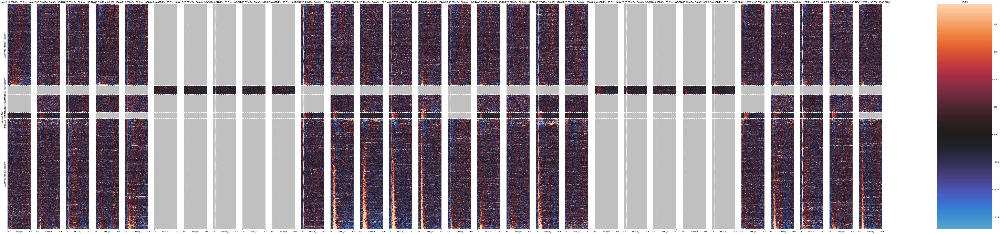

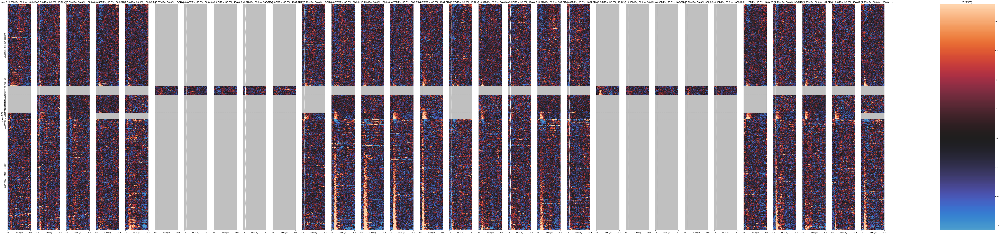

In [ ]:
%%skip $skip_rasters

# Plot activity heatmaps for each variable of interest, sorted by condition
for ykey in ykeys_plt:
    figs[f'{ykey} heatmap'] = plot_activity_heatmap(
        trialagg_timeseries, ykey, fidx, fps, col=Label.RUN,
        col_order=sorted_conds.index.values, 
        col_labels=sorted_conds.values,
        rasterized=True,
        colwrap=len(sorted_conds), 
        sort_ROIs=True,
    )

### Visualize global average trace, along with impact of exclusion criteria (on population-aggregated data)

 2026/10/05 10:56:54: plotting % of excluded samples per dataset, across criteria
 2026/10/05 10:56:54: computing population average data across (dataset, run, trial)...
 2026/10/05 10:56:54: adding time info to table...
 2026/10/05 10:56:54: identifying conditions with >= 5 valid trials
 2026/10/05 10:56:54: adding expanded validity index to timeseries ...
 2026/10/05 10:56:54: filtering timeseries ...
 2026/10/05 10:56:55: identified 86/1376 (6.2%) samples with "discarded" tag
 2026/10/05 10:56:55: identifying conditions with >= 5 valid trials
 2026/10/05 10:56:55: adding expanded validity index to timeseries ...
 2026/10/05 10:56:55: filtering timeseries ...
 2026/10/05 10:56:55: identified 81/1376 (5.9%) samples with "motion" tag
 2026/10/05 10:56:55: identifying conditions with >= 5 valid trials
 2026/10/05 10:56:55: filtered out additional 1 (100.0) samples
 2026/10/05 10:56:55: adding expanded validity index to timeseries ...
 2026/10/05 10:56:55: filtering timeseries ...
 2026/

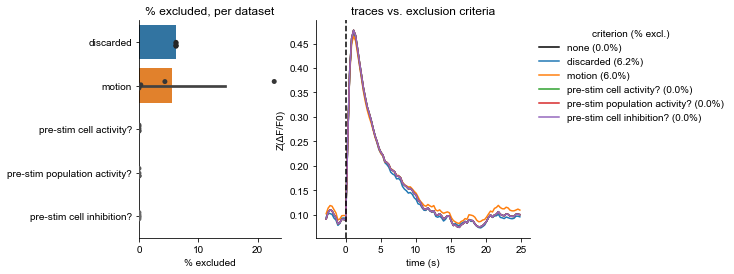

In [11]:
# Plot pct of exclusion per criterion and traces vs exclusion criteria
ykey = Label.ZSCORE
figs['impact of exclusion criteria'], axes = plt.subplots(
    1, 2, figsize=(7, 4), width_ratios=[1, 1.5])
plot_pct_excluded(ext_stats, ax=axes[0])
popagg_stats = get_popavg_data(ext_stats)
plot_traces_vs_exclusion(popagg_timeseries, popagg_stats, ykey, fidx=fidx, ax=axes[1]);

### Plot aggregate response trace for all non-zero conditions, and identify temporal response features and corresponding response analysis window

 2026/10/05 10:56:57: adding 8-column stats information to timeseries...
 2026/10/05 10:57:03: adding time info to table...
 2026/10/05 10:57:04: plotting Z(ΔF/F0) response traces...
 2026/10/05 10:57:14: computing peak features on average trace...
 2026/10/05 10:57:14: response FWHM = 2.48s, corresponding window size = 2.51s (9 frames)
 2026/10/05 10:57:14: overwriting post window size in "/Users/tlemaire/Documents/data/usnm/processed/aggmedian_classzscore_directional/alpha0.7_qadaptive_wq30.0s/suite2p_fs_3.58_reg_tif_tau_1.25/kd_G0.5_V0.05_npad10/submap_0<-1_stim-1->stimeverytrial/PRF/theo_line3/post_window_size.txt"


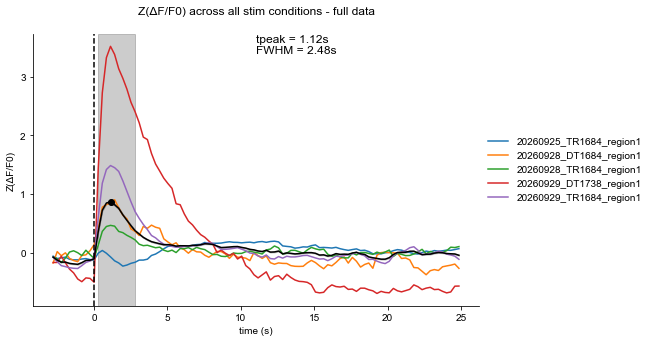

In [12]:
# Add critical stats columns to timeseries data
plt_data = get_plot_data(trialagg_timeseries, trialagg_stats, fidx, keys=Label.MERGE_UPON_PLT + [cond_key, other_cond_key])

# Variable of interest
ykey = Label.ZSCORE

# Flag to add per-dataset traces
dataset_traces = 'full' # 'grey'

# Extract plot data for all non-zero conditions
stim_cond = plt_data[Label.ISPTA] > 0
stim_pltdata = plt_data[stim_cond]

# Plot average trace across datasets
logger.info(f'plotting {ykey} response traces...')
figs[f'{ykey} resp trace merged'], ax = plt.subplots(figsize=(8, 5))
sns.despine(ax=ax)
if dataset_traces:
    sns.lineplot(
        ax=ax,
        data=stim_pltdata,
        x=Label.TIME,
        y=ykey,
        errorbar=None,
        hue=Label.DATASET,
        hue_order=dataset_order,
        palette=get_uniform_palette(stim_pltdata) if dataset_traces == 'grey' else None,
        legend='full' if dataset_traces == 'full' else False,
    )
sns.lineplot(
    ax=ax,
    data=stim_pltdata,
    x=Label.TIME,
    y=ykey,
    errorbar='se',
    color='k' if dataset_traces == 'full' else Palette.LINE[mouseline],
)
ax.axvline(0, ls='--', c='k')
ax.set_title(f'{ykey} across all stim conditions - full data', y=1.05)

# Compute and materialize peak features on average trace
logger.info('computing peak features on average trace...')
s = trialagg_timeseries[stim_cond][ykey].groupby(Label.FRAME).mean()
props = find_response_peak(
    s.loc[fidx.iref:], full_output=True, prominence=0.3 * np.ptp(s), width=1)
tprops = convert_peak_props(props, fps, ioffset=fidx.iref)
tpeak = tprops['index']  # s
ypeak = tprops['value']
FWHM = tprops['widths']  # s
ax.plot(tpeak, ypeak, 'o', c='k')
ax.axvspan(tprops['left_ips'], tprops['right_ips'], color='k', alpha=.2, label='FWHM')

# Mark peak features on figure
txt = [
    f'tpeak = {tpeak:.2f}s',
    f'FWHM = {FWHM:.2f}s',
]

# Compute post-stimulus window size (i.e. number of frames) from extracted FWHM, and save it to file
npost = int(np.round(props['widths']))
logger.info(f'response FWHM = {FWHM:.2f}s, corresponding window size = {npost / fps:.2f}s ({npost} frames)')
save_post_window_size(input_dir, npost)

# Update frame indexer object with corrected post-stimulus window size
fidx.npost = npost

# Add text on axis and legend on right side
ax.text(0.5, 1, '\n'.join(txt), transform=ax.transAxes, va='top', fontsize=12)
if ax.get_legend() is not None:
    sns.move_legend(ax, 'center left', bbox_to_anchor=(1, 0.5), frameon=False)

### Plot traces per condition, with dataset averages and global averages

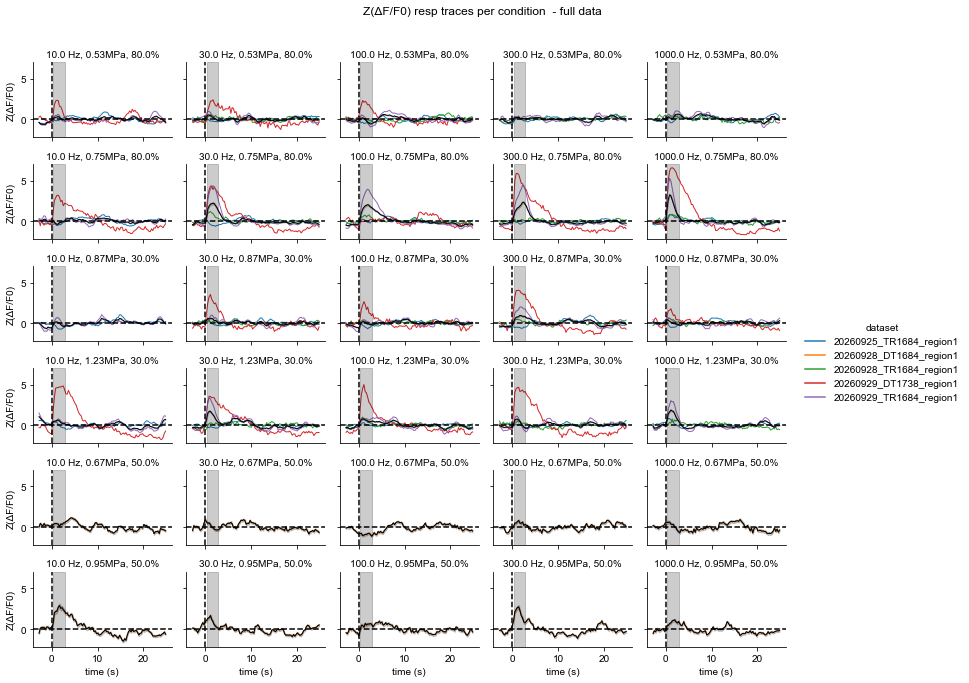

In [ ]:
%%skip $skip_traces

# Variable of interest
ykey = Label.ZSCORE

logger.info(f'plotting {ykey} response traces per condition across datasets...')

# Flag to add per-dataset traces
dataset_traces = 'full'  # 'grey'

# Define FacetGrid with PRF as columns and other condition as rows
g = sns.FacetGrid(
    data=plt_data,
    col=Label.PRF,
    row=other_cond_key,
    aspect=1.5,
    height=1.5,
)

xykeys = dict(
    x=Label.TIME,
    y=ykey,
)

# Plot individual traces for each dataset
g.map_dataframe(
    sns.lineplot,
    **xykeys,
    hue=Label.DATASET,
    hue_order=dataset_order,
    errorbar=None, 
    palette=get_uniform_palette(plt_data) if dataset_traces == 'grey' else None,
    legend='full' if dataset_traces == 'full' else False,
    lw=1,
    zorder=-1,
)
g.add_legend(title=Label.DATASET, bbox_to_anchor=(1, 0.5), frameon=False)
g.set_titles(template='{col_name} Hz, {row_name}')

# Add cross-dataset average traces
g.map_dataframe(
    sns.lineplot,
    **xykeys,
    color='k',
    errorbar='se', 
    lw=1,
    zorder=-1,
)

# Add vertical line at stimulus onset, and horizontal line at 0 
g.refline(x=0, y=0, c='k')
for ax in g.axes.flatten():
    ax.axvspan(tprops['left_ips'], tprops['right_ips'], color='k', alpha=.2)

# Add title
figkey = f'{ykey} resp traces per condition  - full data'
g.fig.suptitle(figkey, y=1.05)
figs[figkey] = g.fig

### Plot global average traces per (P, DC) condition, color-coded by PRF

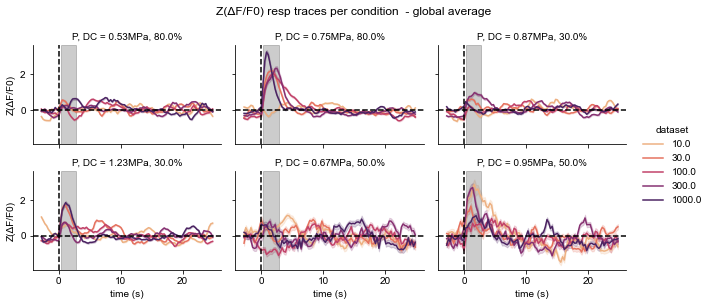

In [ ]:
%%skip $skip_traces

# Variable of interest
ykey = Label.ZSCORE

logger.info(f'plotting {ykey} response traces per condition...')

# Get PRF color palette
cmap = sns.color_palette('flare', as_cmap=True)
PRFs = np.sort(trialagg_stats[Label.PRF].unique())
PRF_palette = {v: cmap(i / (len(PRFs) - 1)) for i, v in enumerate(PRFs)}

# Define FacetGrid
g = sns.FacetGrid(
    data=plt_data,
    col=other_cond_key,
    col_wrap=3,
    aspect=1.5,
    height=2,
)
g.map_dataframe(
    sns.lineplot,
    x=Label.TIME,
    y=ykey,
    errorbar='se',
    hue=Label.PRF,
    palette=PRF_palette,
    legend='full',
)
g.add_legend(title=Label.DATASET, bbox_to_anchor=(1, 0.5), frameon=False)

# Add vertical line at stimulus onset, and horizontal line at 0 
g.refline(x=0, y=0, c='k')
for ax in g.axes.flatten():
    ax.axvspan(tprops['left_ips'], tprops['right_ips'], color='k', alpha=.2)

# Add title
figkey = f'{ykey} resp traces per condition  - global average'
g.fig.suptitle(figkey, y=1.05)
figs[figkey] = g.fig

## Parameter dependency curves

### Compute and plot initial parameter dependency curves with appropriate response window size

 2026/10/05 10:58:00: applying mean function on ΔF/F0 in [5-11] index window across dataset, ROI, run
 2026/10/05 10:58:00: applying mean function on ΔF/F0 in [11-20] index window across dataset, ROI, run
 2026/10/05 10:58:00: computing evoked ΔF/F0 change...
 2026/10/05 10:58:00: applying mean function on Z(ΔF/F0) in [5-11] index window across dataset, ROI, run
 2026/10/05 10:58:00: applying mean function on Z(ΔF/F0) in [11-20] index window across dataset, ROI, run
 2026/10/05 10:58:00: computing evoked Z(ΔF/F0) change...


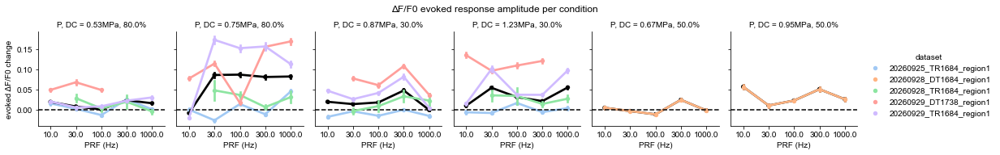

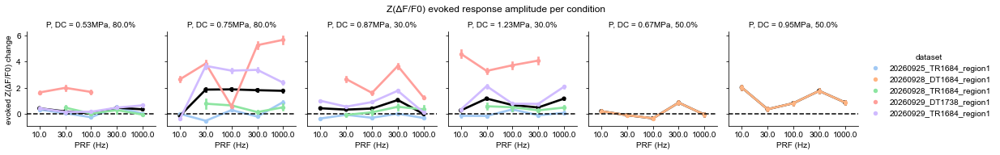

In [15]:
# Variables of interest
ykeys = [
    Label.DFF,
    Label.ZSCORE
]

# Whether to add detailed dataset traces
details = True

# Compute evoked responses for each variable of interest
for ykey in ykeys:
    ykey_diff = get_change_key(ykey)
    trialagg_stats[ykey_diff] = compute_evoked_change(
        trialagg_timeseries, ykey, fidx)

for ykey in ykeys:
    g = sns.FacetGrid(
        data=trialagg_stats.reset_index(),
        col=other_cond_key,
        aspect=1,
        height=2.5,
    )
    g.map_dataframe(
        sns.pointplot,
        x=Label.PRF,
        y=get_change_key(ykey),
        color='k',
        errorbar='se',
        markers='.',
    )
    g.map_dataframe(
        sns.pointplot,
        x=Label.PRF,
        y=get_change_key(ykey),
        hue=Label.DATASET,
        hue_order=dataset_order,
        palette='pastel',
        errorbar='se',
        markers='.',
    )
    g.refline(y=0, c='k', ls='--')
    g.add_legend(title=Label.DATASET, bbox_to_anchor=(1, 0.5), frameon=False)
    figkey = f'{ykey} evoked response amplitude per condition'
    g.fig.suptitle(figkey, y=1.05)
    figs[figkey] = g.fig

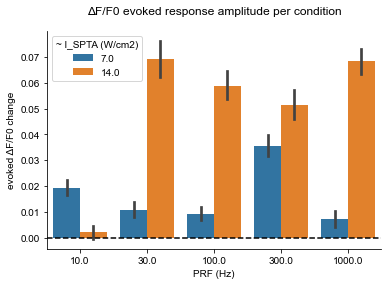

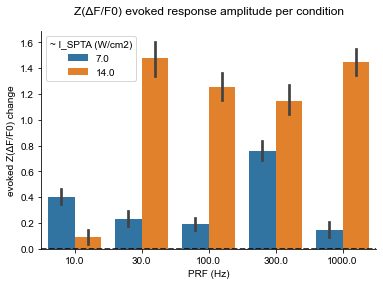

In [29]:
# Variables of interest
ykeys = [
    Label.DFF,
    Label.ZSCORE
]

trialagg_stats[f'~ {Label.ISPTA}'] = trialagg_stats[Label.ISPTA].round()

for ykey in ykeys:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.despine(ax=ax)
    sns.barplot(
        data=trialagg_stats.reset_index(),
        x=Label.PRF,
        y=get_change_key(ykey),
        # style=Label.ISPTA,
        hue=f'~ {Label.ISPTA}',
        dodge=True,
        # linestyles=
        # color='k',
        # errorbar='se',
        # markers='.',
    )
    ax.axhline(0, c='k', ls='--')
    figkey = f'{ykey} evoked response amplitude per condition'
    ax.set_title(figkey, y=1.05)
    figs[figkey] = fig

### Classify responses and responders

In [ ]:
# Classify responses based on response z-score values
zthr = pvalue_to_zscore(PTHR_DETECTION, directional=directional)
trialagg_stats[Label.RESP_TYPE] = zscore_to_resp_type(
    trialagg_stats[ykey_diff], zthr, directional=directional)

# Classify responders based on fraction of non-weak responses across experiment
roistats = classify_ROIs(trialagg_stats, directional=directional)
ext_stats = free_expand_and_add(roistats, ext_stats.copy())
trialagg_stats = free_expand_and_add(roistats, trialagg_stats.copy())

 2025/10/27 16:15:22: classifying responses using directional z-score thresholding ...
 2025/10/27 16:15:22: computing fraction of response occurence per ROI over 9 "strong ISPTA" conditions...
 2025/10/27 16:15:22: classiying ROIs as a function of their response occurence fractions...
 2025/10/27 16:15:24: expanding (17 datasets x 1145 ROIs) input dataframe to match (17 datasets x 1145 ROIs x 15 runs x 16 trials) reference dataframe
 2025/10/27 16:15:34: expanding (17 datasets x 1145 ROIs) input dataframe to match (17 datasets x 1145 ROIs x 15 runs) reference dataframe


### ROI breakdown per dataset

 2026/10/02 01:23:39: computing fraction of response occurence per ROI over 30 "strong ISPTA" conditions...
 2026/10/02 01:23:39: identified 12.5% of responders with 0.5 as threshold proportion of responding conditions
 2026/10/02 01:23:39: plotting cell maps...


100%|██████████| 5/5 [00:16<00:00,  3.35s/it]


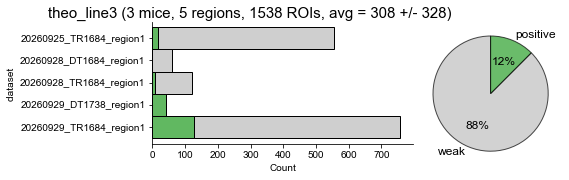

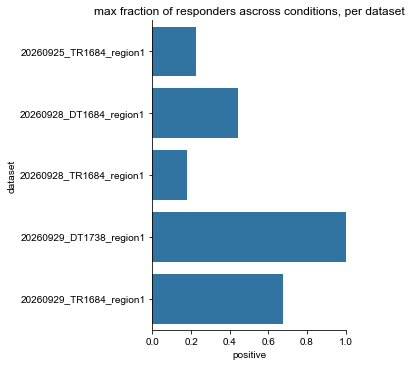

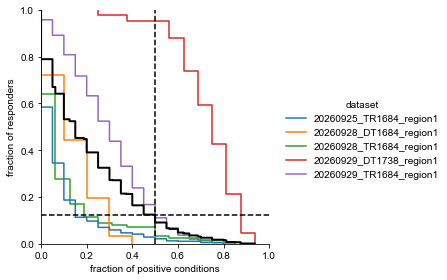

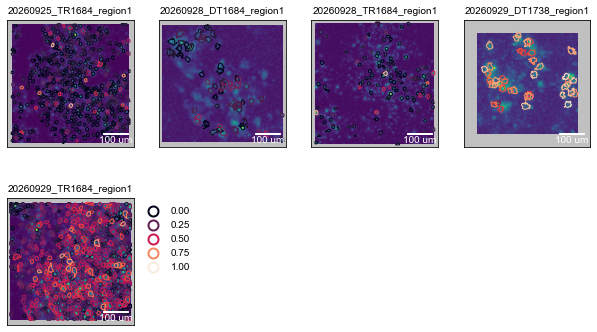

In [133]:
# Plot cell count distribution and breakdown
figs['rtype dist per mousereg'] = plot_cellcounts(
    trialagg_stats, hue=Label.ROI_RESP_TYPE, title=mouseline)

# Plot distribution of max number of responders across conditions 
resp_counts = (
    trialagg_stats[Label.RESP_TYPE]
    .groupby([Label.DATASET, Label.RUN])
    .value_counts().unstack()
)
resp_counts['total'] = resp_counts.sum(axis=1)
resp_props = resp_counts.div(resp_counts['total'], axis=0)
max_pos_props= resp_props['positive'].groupby(Label.DATASET).max()
max_pos_props = max_pos_props.to_frame().reset_index()
fg = sns.catplot(
    data=max_pos_props,
    kind='bar', 
    x='positive', 
    y=Label.DATASET,
    color='C0'
)
fg.figure.axes[0].set_xlim(0, 1)
fg.figure.axes[0].set_title('max fraction of responders ascross conditions, per dataset')
figs['max % resp'] = fg.figure

# Plot cell classification details 
figs['classification details'] = plot_classification_details(
    trialagg_stats, pthr=PROP_CONDS_THR, hue=Label.DATASET)

# Plot cell maps
figs['cellmaps with rtype'] = plot_fields_of_view(
    map_ops, 
    ROI_masks=ROI_masks,
    Fstats=trialagg_stats, 
    refkey='Vcorr', 
    mode='contour', 
    hue='positive'
)

### Save figures

In [ ]:
figs = {k: v for k, v in figs.items() if v is not None}
save_figs_book(figsdir, figs, suffix=figs_suffix)

 2025/10/28 13:16:29: saving figures in /Users/tlemaire/Documents/data/usnm/figs/2025.10.28/figs_main_pv_linreg_robust_k0.5_alpha0.7_qadaptive_wq30.0s_aggmedian_classzscore_directional.pdf:


100%|██████████| 11/11 [00:02<00:00,  4.34it/s]


### Notify upon completion

In [ ]:
# Get time stamp from notebook completion
tstamp_end = datetime.datetime.now()

# Log completion process
s = f'{mouseline} batch notebook completed in {tstamp_end - tstamp_start} s'
if slack_notify:
    jupyter_slack.notify_self(s)
logger.info(s)

 2025/10/27 16:21:21: sst batch notebook completed in 0:08:34.012646 s
